# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [2]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo/'#'Cr-Co-W'#
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer

In [3]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)
Features = Featurizer(BS)

# Compositions 

# Population of phases

<AxesSubplot:xlabel='Phase', ylabel='Count'>

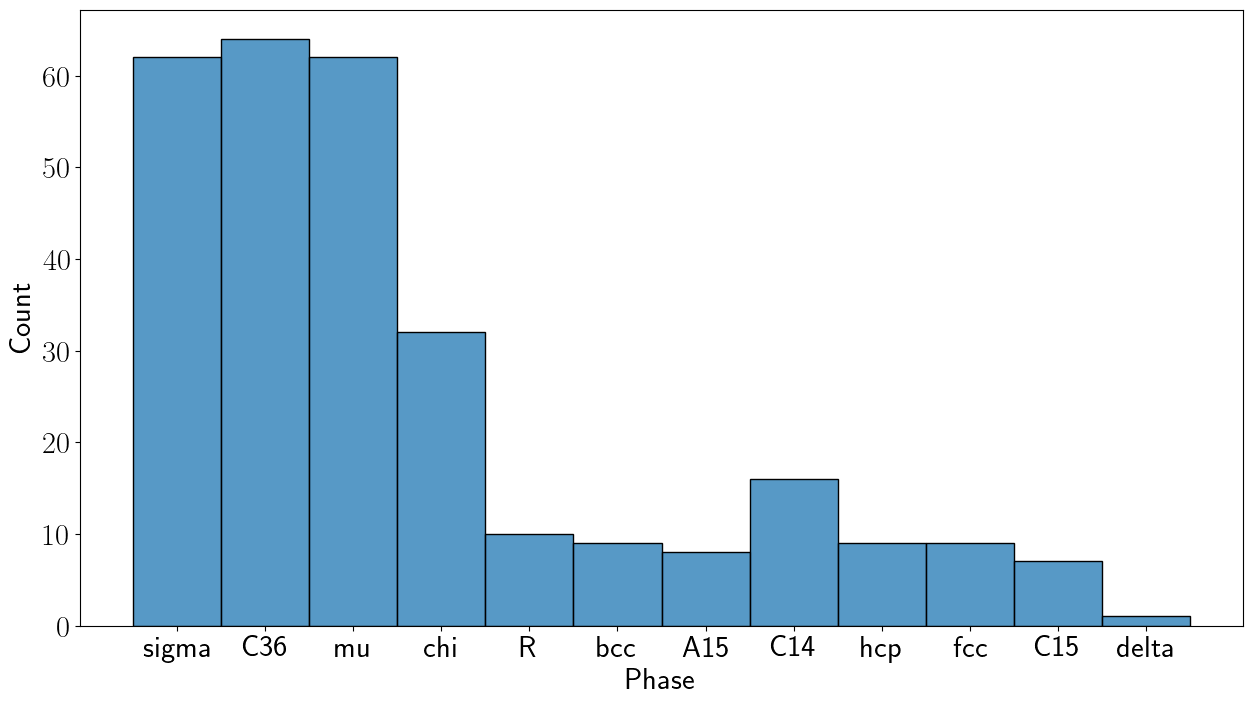

In [4]:
fig, ax = plt.subplots(figsize=(15,8))
sns.histplot(x = BS['Phase'], ax=ax)

<AxesSubplot:ylabel='Count'>

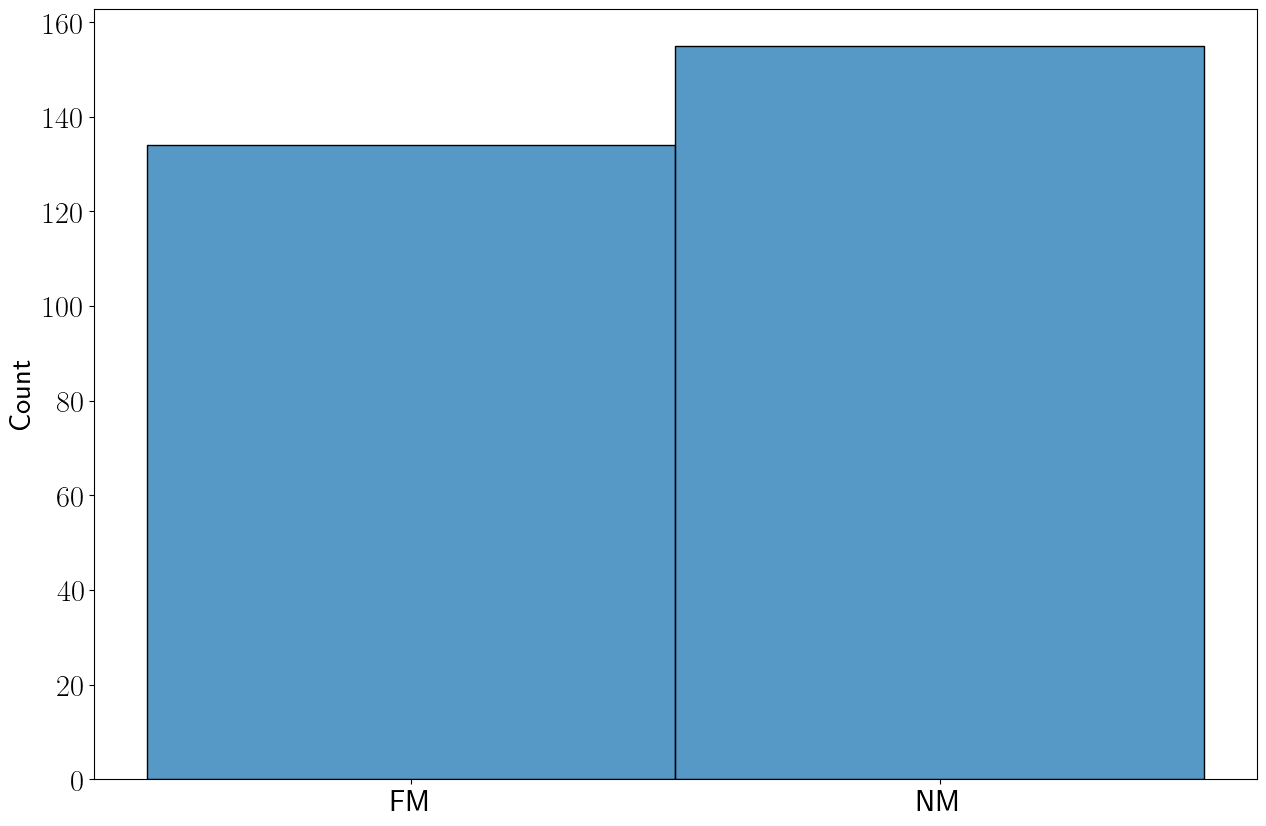

In [5]:
sns.histplot(x = Features.Mag)

In [6]:
isfm = Features.Mag.str.contains('FM')

In [7]:
fmsamples = BS.index[isfm]

In [8]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [9]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [10]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv13.mu.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv1Mo_sv1.L10-NiAl-AB.NM', 'Fe_pv1Mo_sv3.D03-AB3.NM',
       'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM',
       'Fe_pv2Mo_sv11.mu-BBBBA.NM', 'Fe_pv2Mo_sv2.B32-AB.NM',
       'Fe_pv33Mo_sv20.R-AAAAAAABBBB.NM', 'Fe_pv37Mo_sv14.R-AAAAAAAABBB.NM',
       'Fe_pv3Mo_sv1.D03-A3B.NM', 'Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM',
       'Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM', 'Fe_pv4Mo_sv26.sigma-BABBB.NM',
       'Fe_pv53.R.NM', 'Fe_pv6.C15.NM', 'Fe_pv6Mo_sv2.D0_19-A3B.NM',
       'Fe_pv6Mo_sv24.sigma-AABBB.NM', 'Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM',
       'Mo_sv53.R.NM', 'Mo_sv56.delta.NM'],
      dtype='object', name='index')

## nm samples as without fm counterpart:

In [11]:
fmsamplesasnm.difference(nmsamples)

Index([], dtype='object', name='index')

#  Obvious outliers removal

In [12]:
BS = BS[(BS.B0 > 0 ) ]

# Distribution of Target Variables 

## total energy

In [13]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [14]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

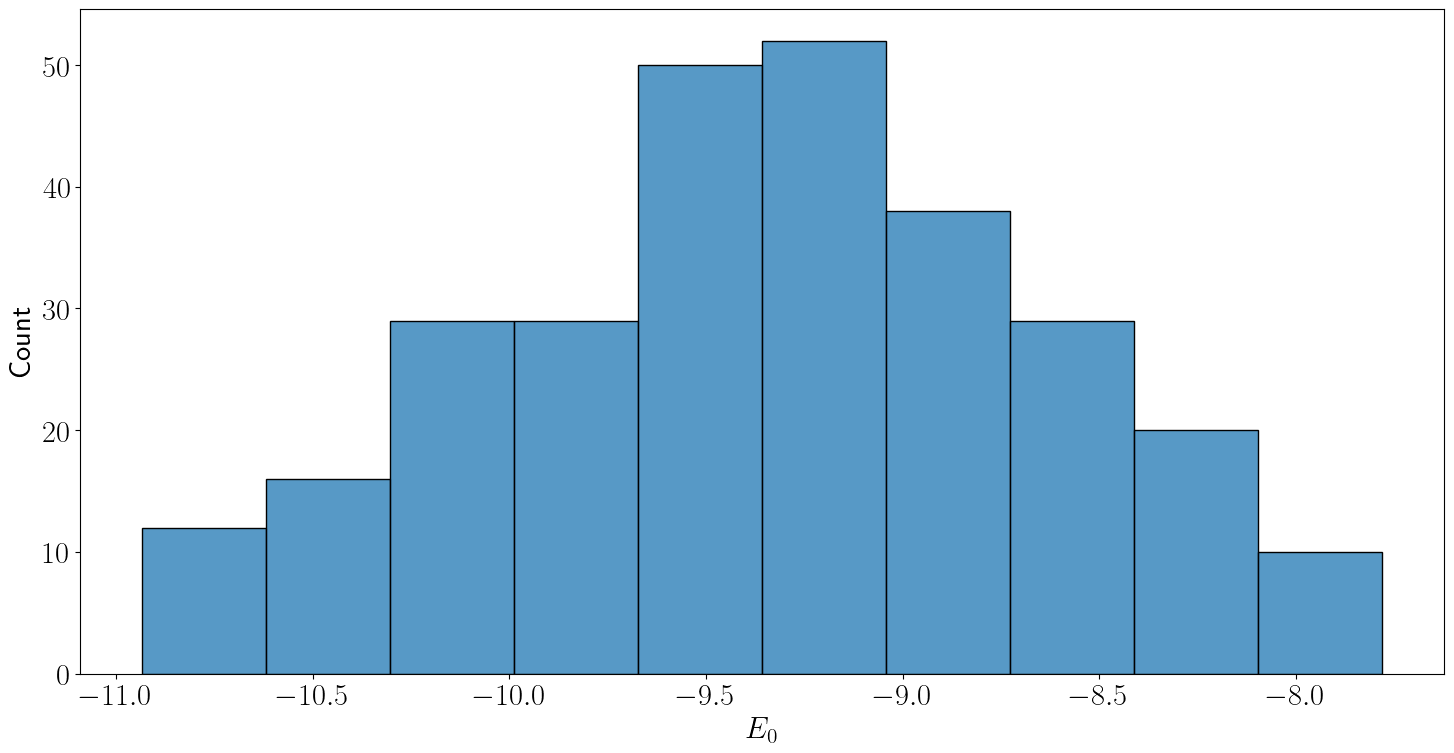

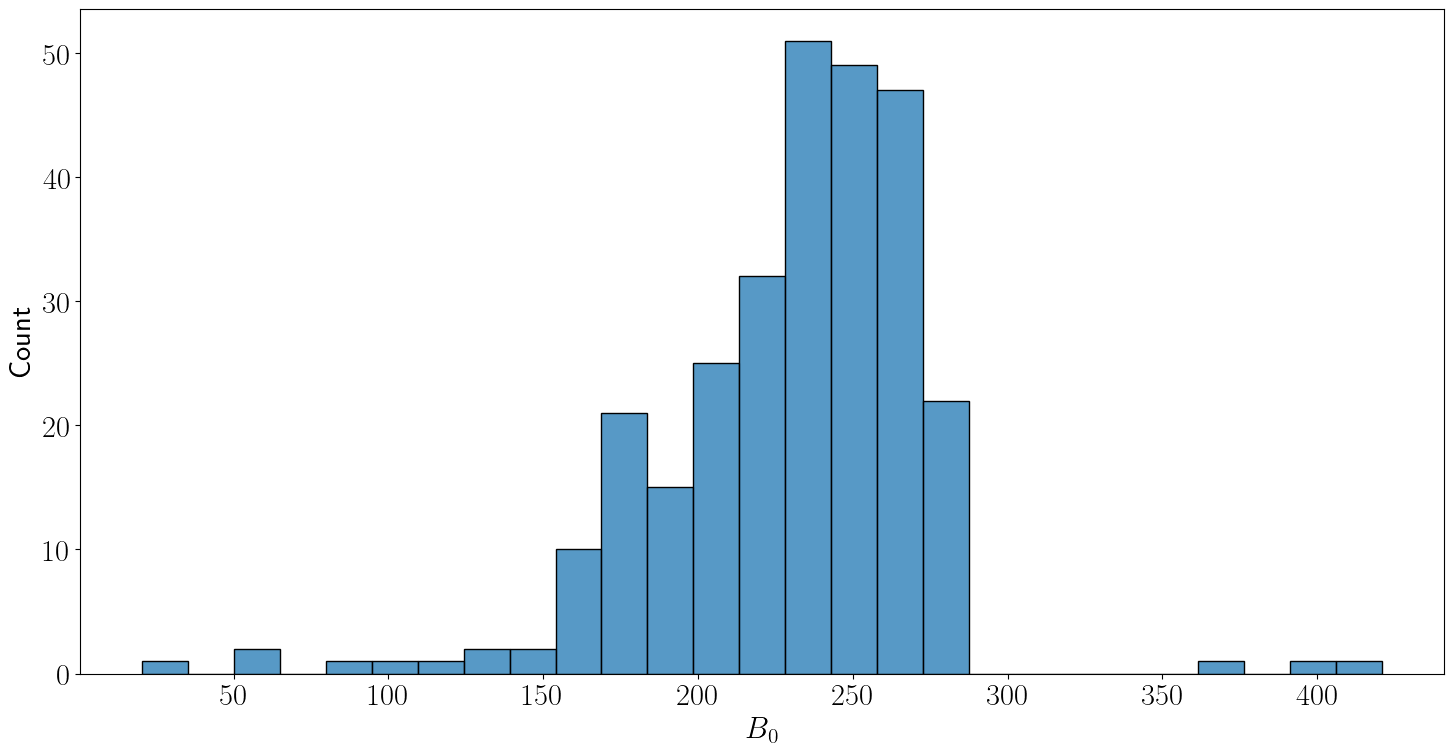

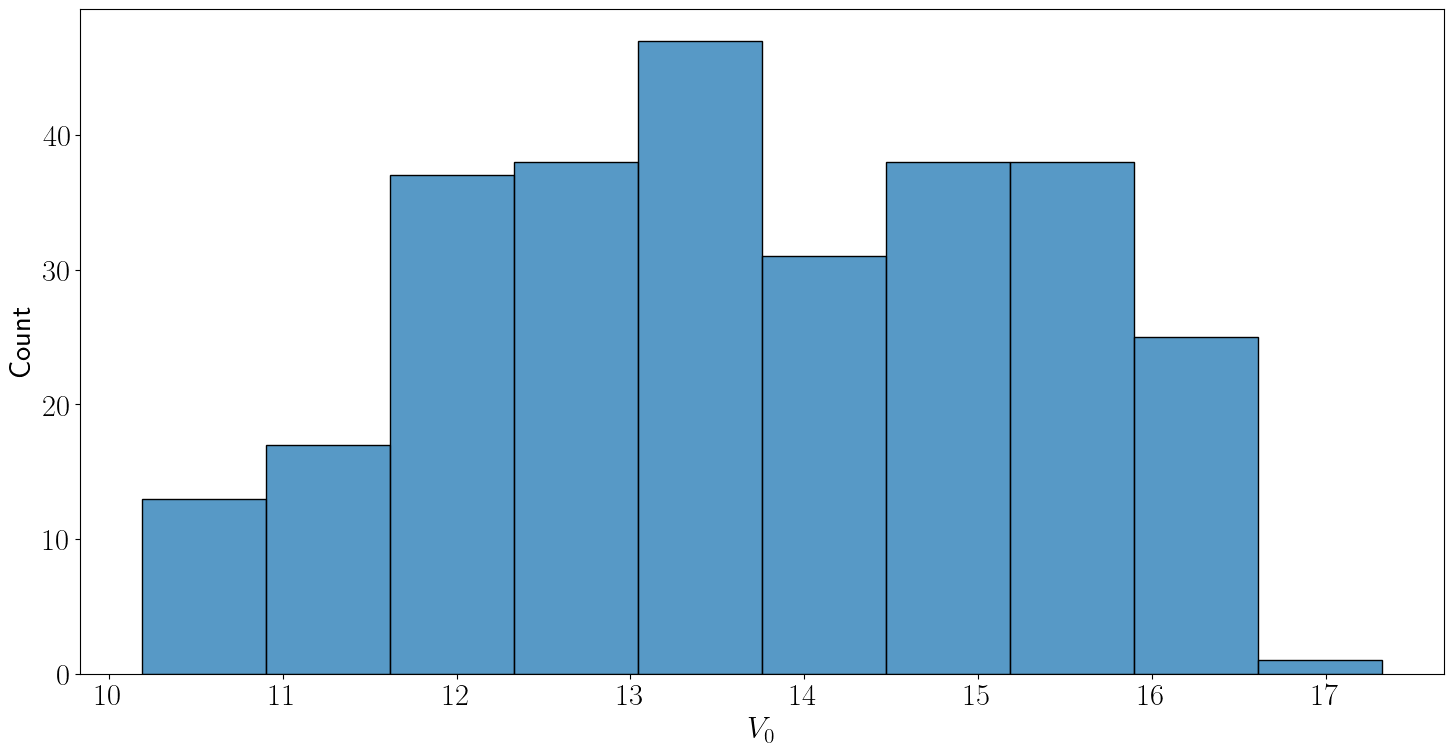

In [15]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [16]:
BS.sort_values(by='B0', inplace=True)

Text(14.595271, -9.414958, 'Fe_pv3Mo_sv10.mu-ABBBA.FM')

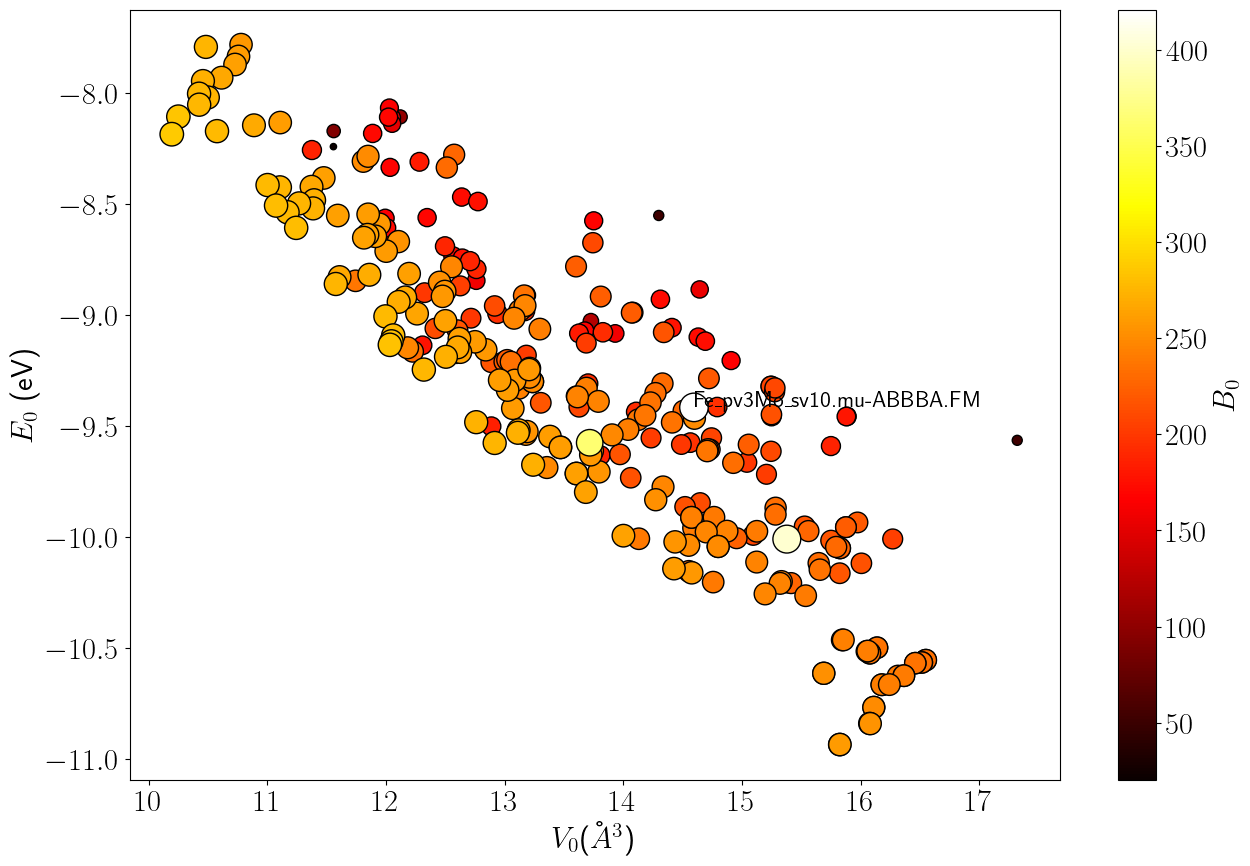

In [20]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])
#outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
#plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
outlier_high_b0 = BS[BS['B0']>400].index
plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

## Very low B0 or very High B0 
Achnung! numberss depend on system ! change to automatic detection !

In [26]:
BS[(BS['B0'] < 150) | (BS['B0']>350)].B0.sort_values()

Series([], Name: B0, dtype: float64)

## curate suspicious samples based on B0

In [27]:
BS = BS[(BS['B0'] > 150) & (BS['B0'] < 350)] #.B0.sort_values()

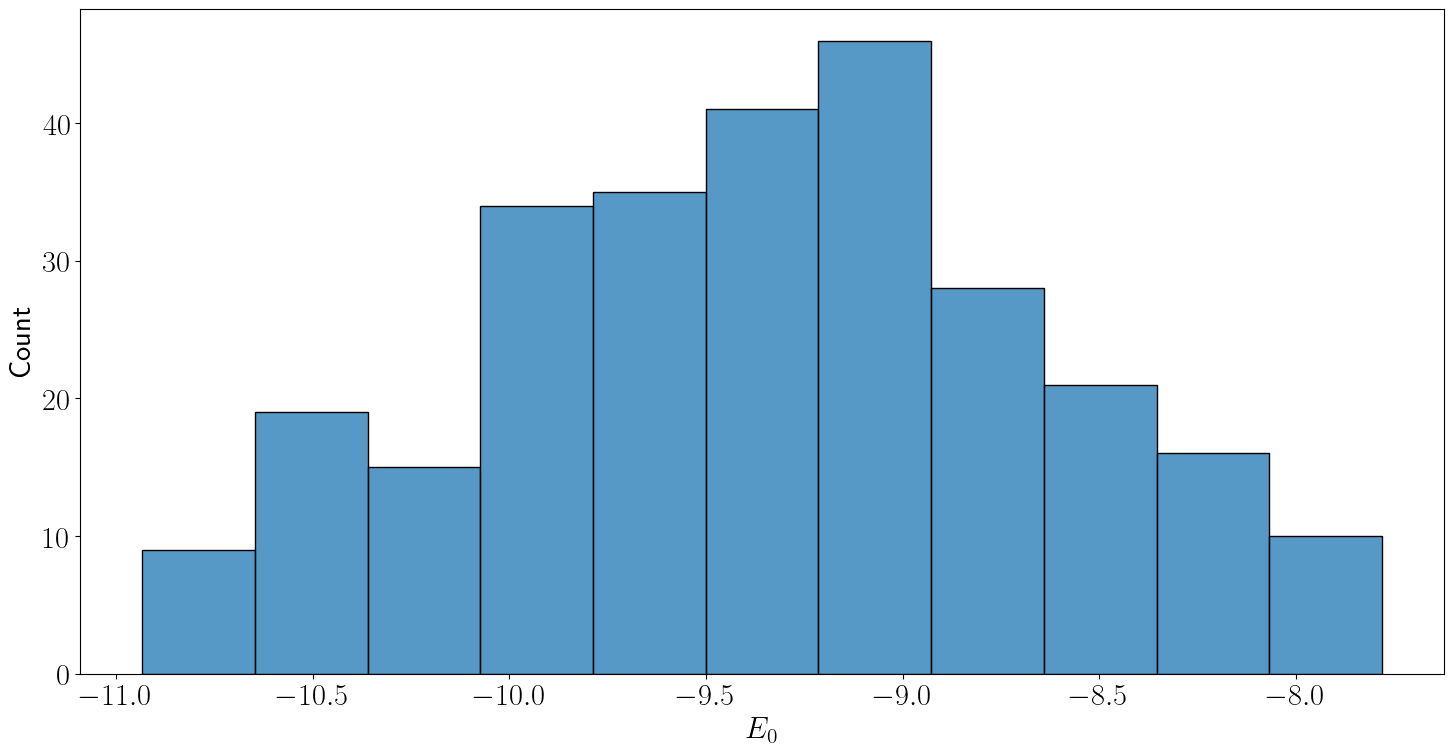

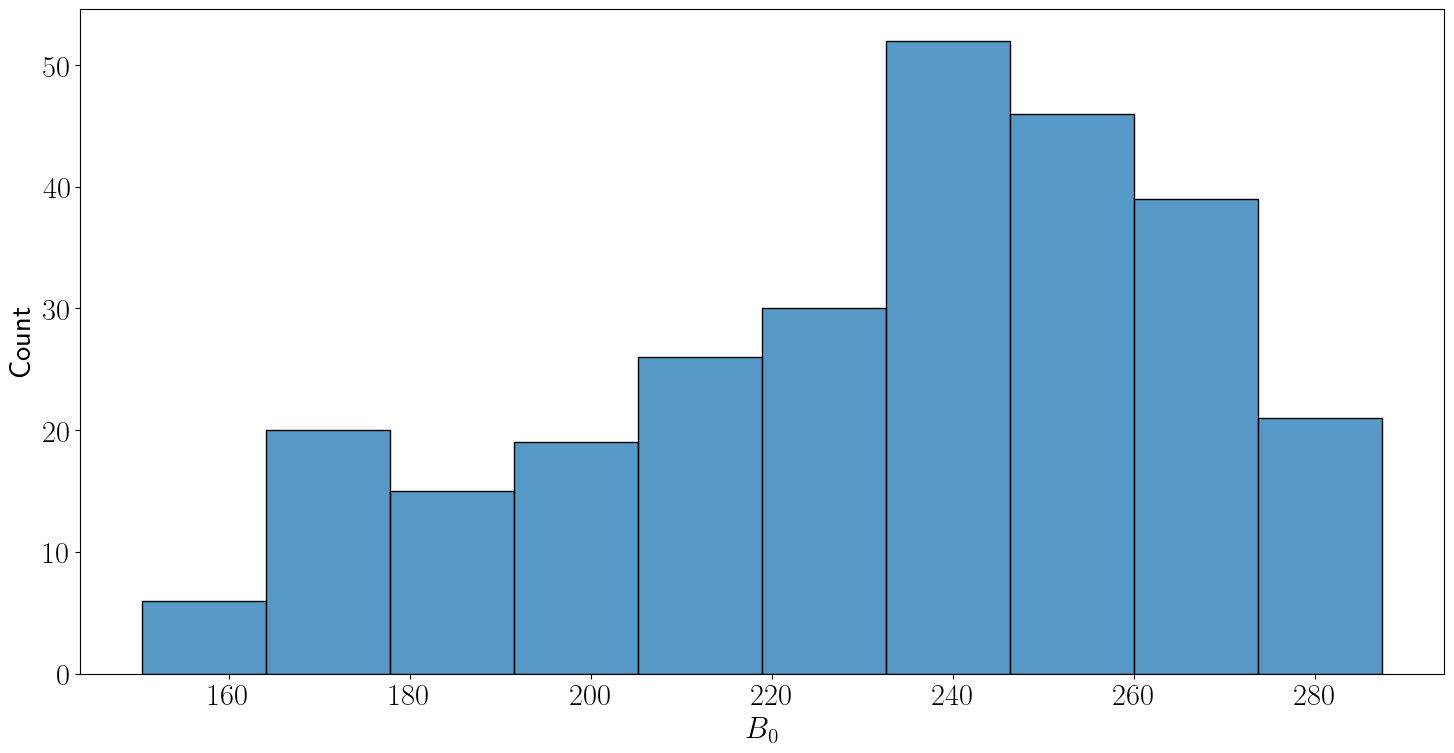

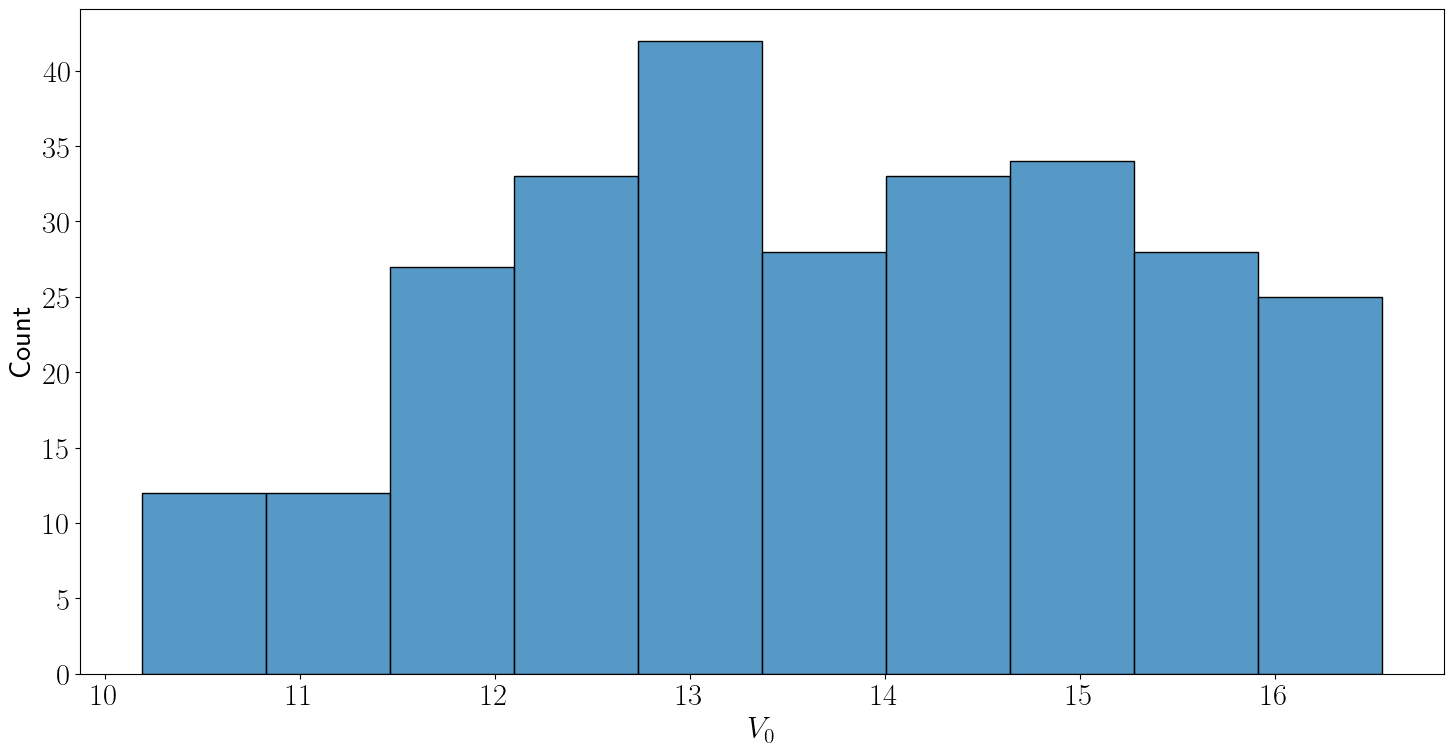

In [28]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# Pair Plots

In [29]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

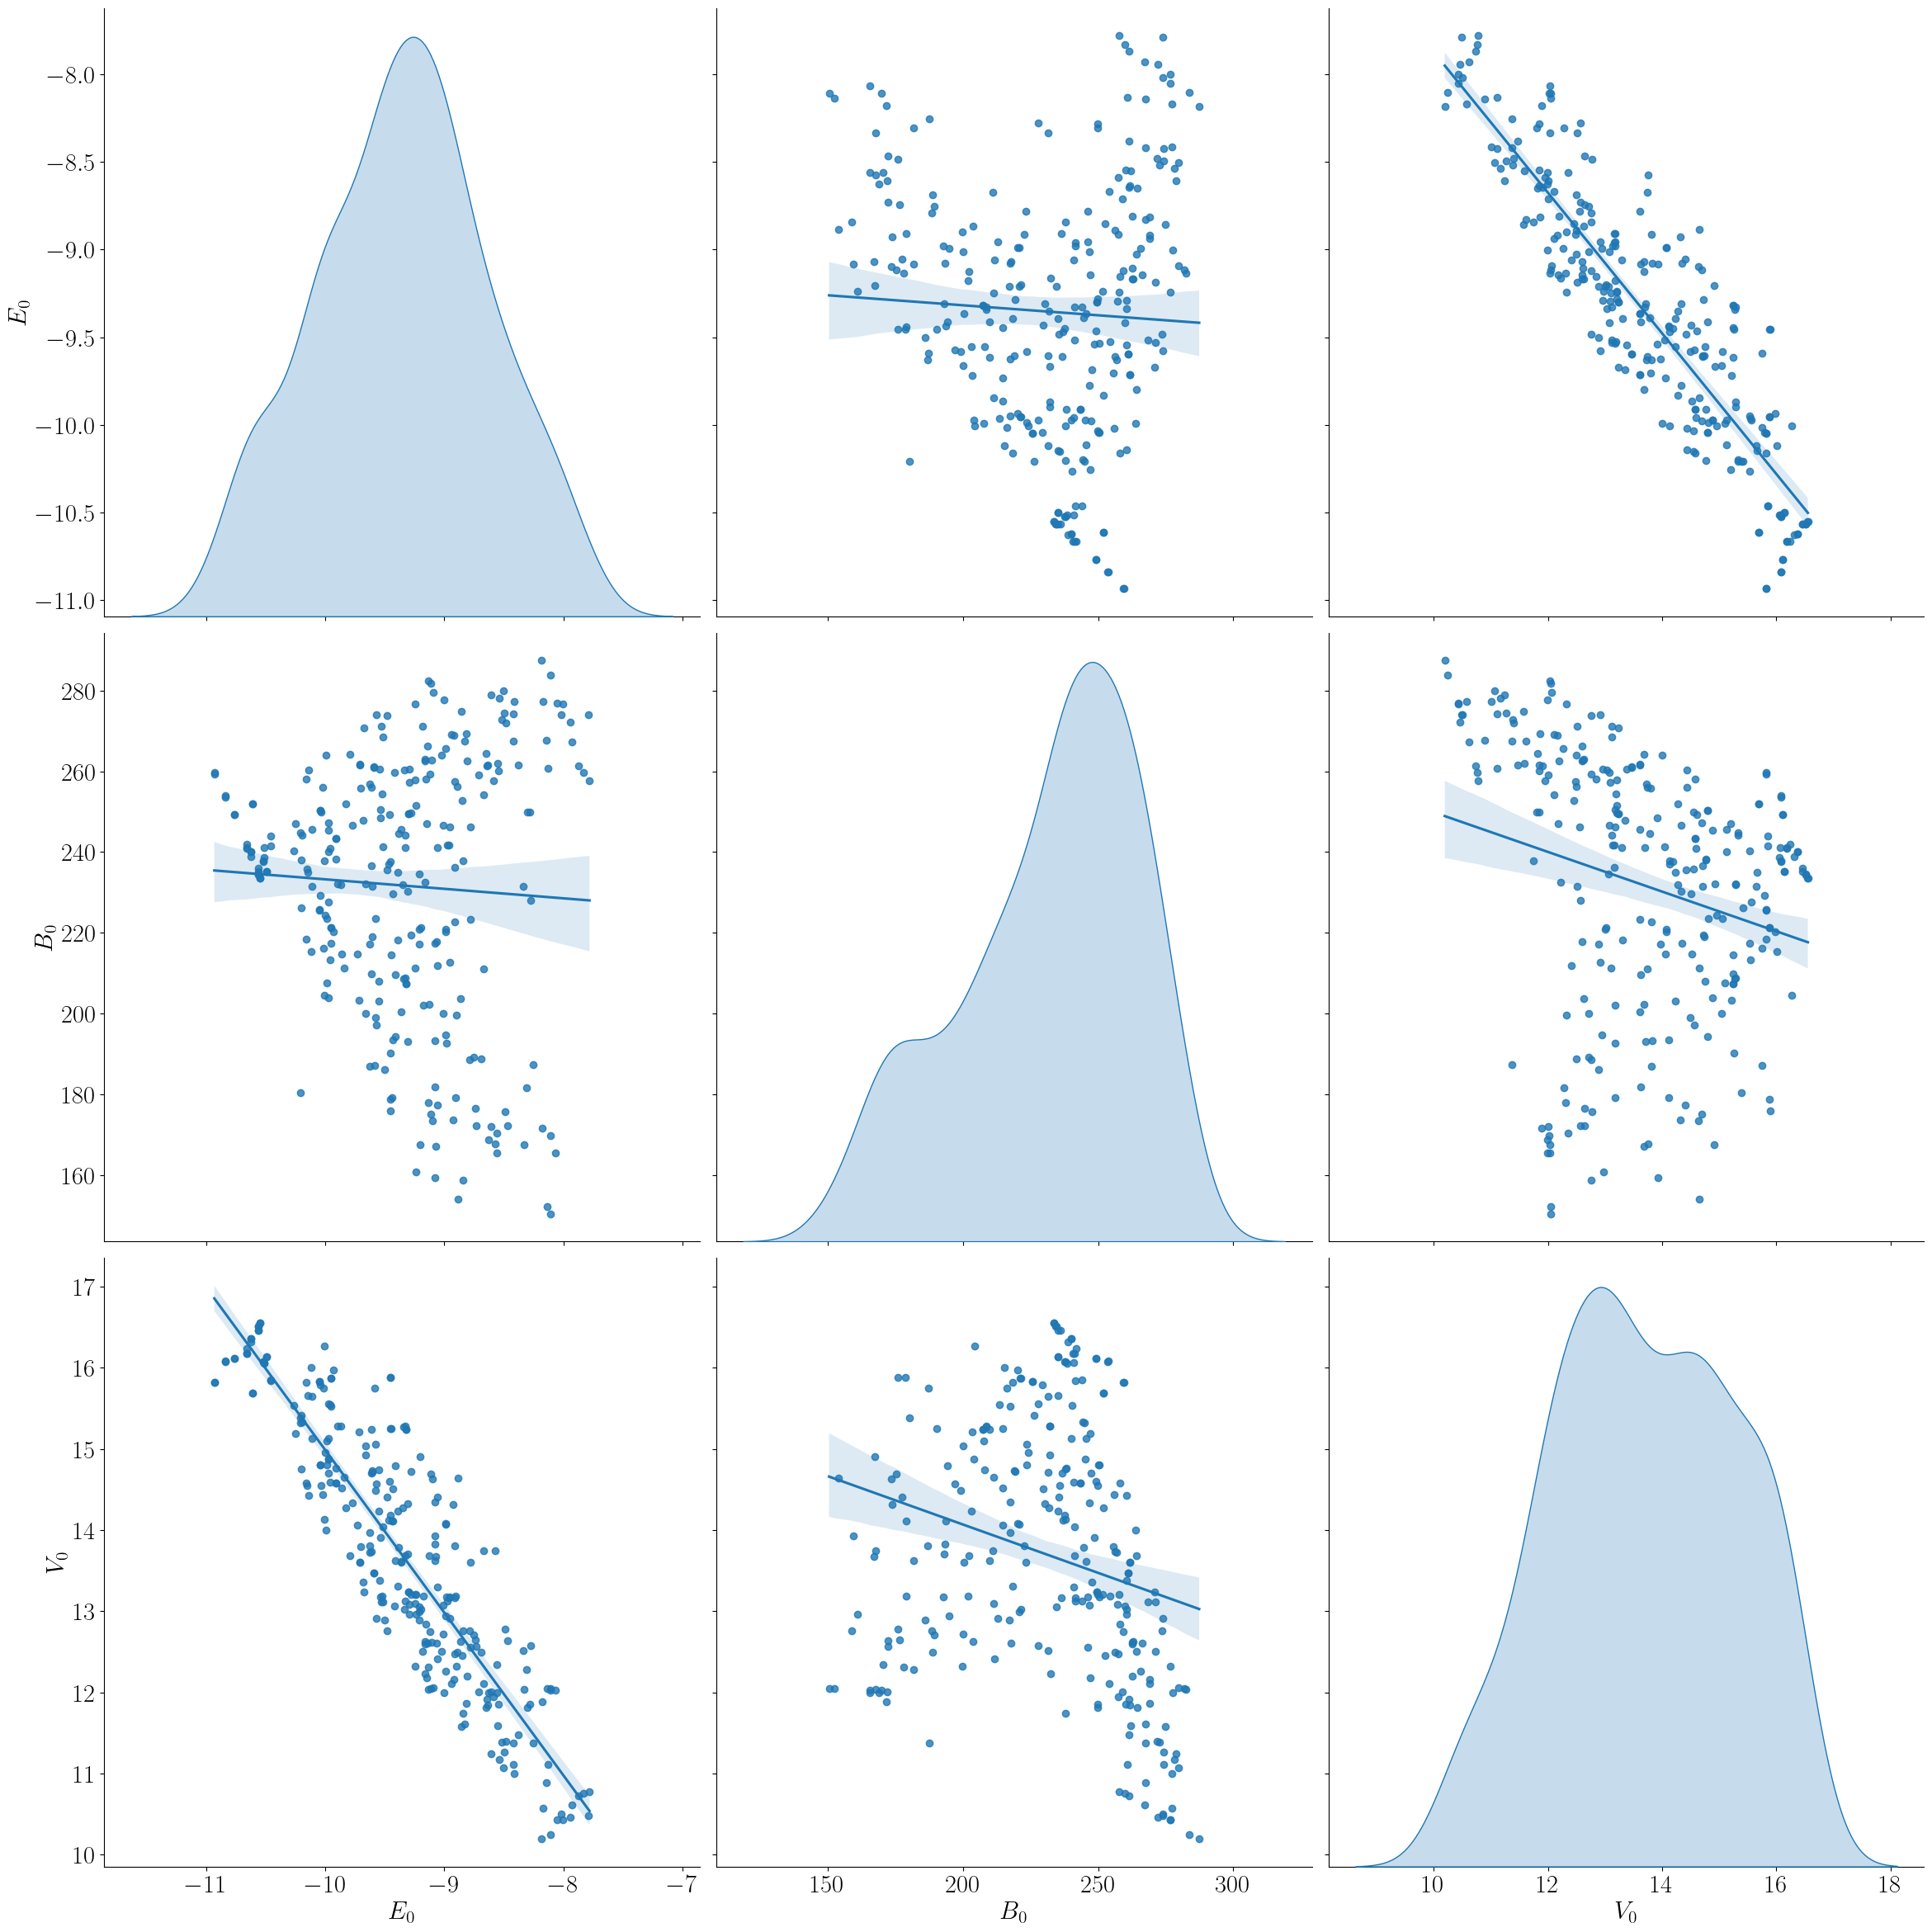

In [30]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [31]:
import pandas as pd
from scipy.spatial import ConvexHull

In [32]:
PhaseBS = {}
verts = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

In [33]:
for phase, bs in PhaseBS.items():
    if bs.shape[0] <= 1:
        continue  # cant make CH with less than 1 sample
    chull = ConvexHull(bs[['Fe_pv','EF']])
    verts[phase] = chull.vertices

In [34]:
irrelevant = ['sigma', 'chi', 'hcp','A15','C15' ,'fcc']

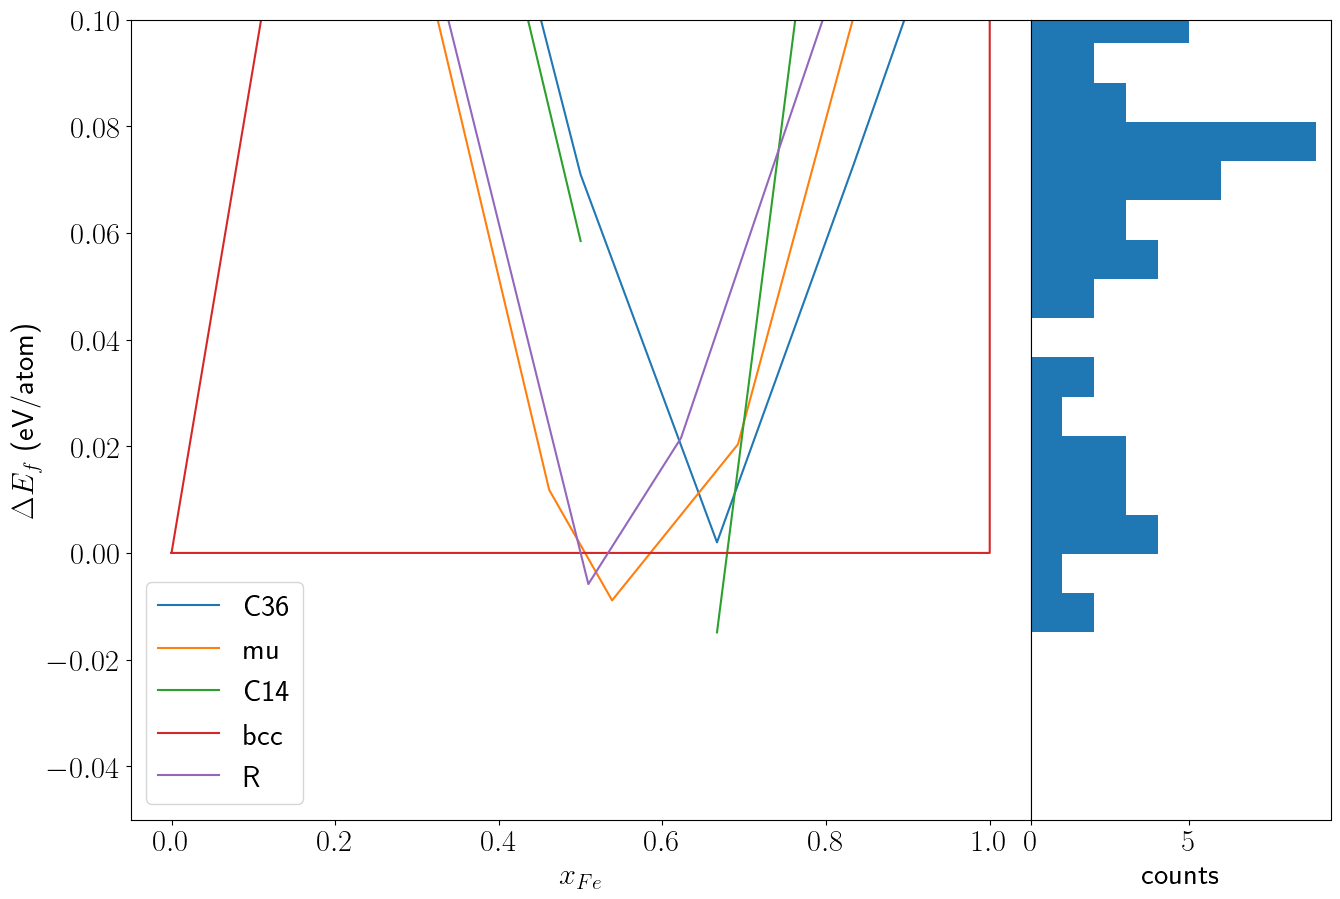

In [35]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    if phase not in irrelevant:
    #    plt.plot(bs['Fe_pv'], bs['EF'], 'o')
        ax.plot(PhaseBS[phase]['Fe_pv'][vertices], PhaseBS[phase]['EF'][vertices], label=phase)
ax.set_ylim([-0.05, 0.1])
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel('$x_{Fe}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()

In [36]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))

# Compositions

In [37]:
import plotly.express as pe

In [38]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Fe_pv24.C36.FM,bulk C36.FM,12.049606 A,-8.109714,150.452690 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,24,0,0,24.0,1.000000,0.000000,0.14558,C36
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137048,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,,29,0,0,29.0,1.000000,0.000000,0.118246,chi
Fe_pv14Mo_sv10.C36-AABAB.FM,bulk C36-AABAB.FM,14.643681 A,-8.883492,154.045319 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,14,10,0,24.0,0.583333,0.416667,0.488047,C36
Fe_pv22Mo_sv8.sigma-AAAAB.FM,bulk sigma-AAAAB.FM,12.759638 A,-8.843901,158.862435 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,22,8,0,30.0,0.733333,0.266667,0.12579,sigma
Fe_pv14Mo_sv10.C36-ABAAB.FM,bulk C36-ABAAB.FM,13.931013 A,-9.081825,159.466599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,14,10,0,24.0,0.583333,0.416667,0.289714,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,25,4,0,29.0,0.862069,0.137931,0.119258,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,16,8,0,24.0,0.666667,0.333333,0.030551,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,4,0,12.0,0.666667,0.333333,0.015189,C14


In [39]:
pe.scatter_ternary(B)

NameError: name 'B' is not defined